<a href="https://colab.research.google.com/github/asishprusty/CSW-1/blob/main/Toursim_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install xgboost joblib openpyxl

In [3]:
import pandas as pd

# Load all the raw data files
transaction = pd.read_excel("Transaction.xlsx")
user = pd.read_excel("User.xlsx")
city = pd.read_excel("City.xlsx")
country = pd.read_excel("Country.xlsx")
region = pd.read_excel("Region.xlsx")
continent = pd.read_excel("Continent.xlsx")
mode = pd.read_excel("Mode.xlsx")
item = pd.read_excel("Item.xlsx")
attraction_type = pd.read_excel("Type.xlsx")

print("Transaction rows:", len(transaction))
print("User rows:", len(user))
print("City rows:", len(city))
print("Country rows:", len(country))
print("Region rows:", len(region))
print("Continent rows:", len(continent))
print("Mode rows:", len(mode))
print("Item rows:", len(item))
print("Type rows:", len(attraction_type))

user_full = user.merge(city[["CityId", "CityName"]], on="CityId", how="left")
user_full = user_full.merge(country[["CountryId", "Country"]], on="CountryId", how="left")
user_full = user_full.merge(region[["RegionId", "Region"]], on="RegionId", how="left")
user_full = user_full.merge(continent[["ContinentId", "Continent"]], on="ContinentId", how="left")

print("\nUser table with readable location names:")
print(user_full.head())

item_full = item.merge(attraction_type, on="AttractionTypeId", how="left")

master = transaction.merge(user_full, on="UserId", how="left")
master = master.merge(item_full, on="AttractionId", how="left")
master = master.merge(mode, left_on="VisitMode", right_on="VisitModeId", how="left")

print("\nMaster dataset shape:", master.shape)
print("\nMaster dataset columns:", list(master.columns))
print("\nFirst few rows:")
print(master.head())

master = master.drop(columns=["VisitMode_x", "VisitModeId"])
master = master.rename(columns={"VisitMode_y": "VisitMode"})

print("\nCleaned master dataset columns:", list(master.columns))
print("\nAny missing values left?")
print(master.isnull().sum())

print("\nRows with missing CityName:")
print(master[master["CityName"].isnull()][["TransactionId", "UserId", "Country", "Region", "Continent"]])

print("\nCount of placeholder ('-') values per column:")
for col in ["CityName", "Country", "Region", "Continent", "VisitMode", "AttractionType"]:
    placeholder_count = (master[col] == "-").sum()
    print(f"{col}: {placeholder_count}")

    master["CityName"] = master["CityName"].fillna("Unknown")
master["CityId"] = master["CityId"].fillna(0)
master["Region"] = master["Region"].replace("-", "Unknown")

print("\nFinal check - missing values:")
print(master.isnull().sum().sum())
print("\nFinal check - placeholder ('-') count in Region:", (master["Region"] == "-").sum())

master.to_csv("master_cleaned.csv", index=False)
print("\nSaved cleaned dataset to master_cleaned.csv")
print("Final shape:", master.shape)


Transaction rows: 52930
User rows: 33530
City rows: 9143
Country rows: 165
Region rows: 22
Continent rows: 6
Mode rows: 6
Item rows: 30
Type rows: 17

User table with readable location names:
   UserId  ContinentId  RegionId  CountryId  CityId    CityName       Country  \
0      14            5        20        155   220.0       Lagos      Portugal   
1      16            3        14        101  3098.0     Jakarta     Indonesia   
2      20            4        15        109  4303.0  Gold Coast     Australia   
3      23            1         4         22   154.0    Meyerton  South Africa   
4      25            3        14        101  3098.0     Jakarta     Indonesia   

            Region            Continent  
0  Southern Europe               Europe  
1  South East Asia                 Asia  
2        Australia  Australia & Oceania  
3  Southern Africa               Africa  
4  South East Asia                 Asia  

Master dataset shape: (52930, 22)

Master dataset columns: ['Transac

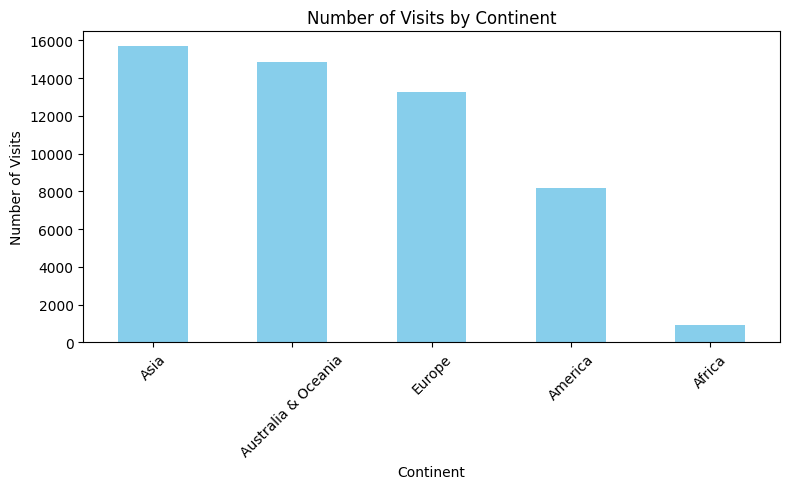

Chart saved as continent_visits.png


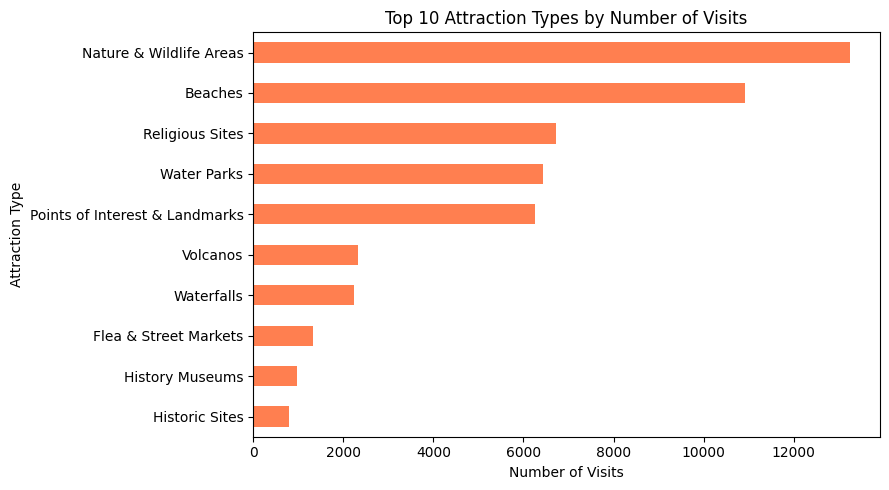

Chart saved as attraction_type_popularity.png


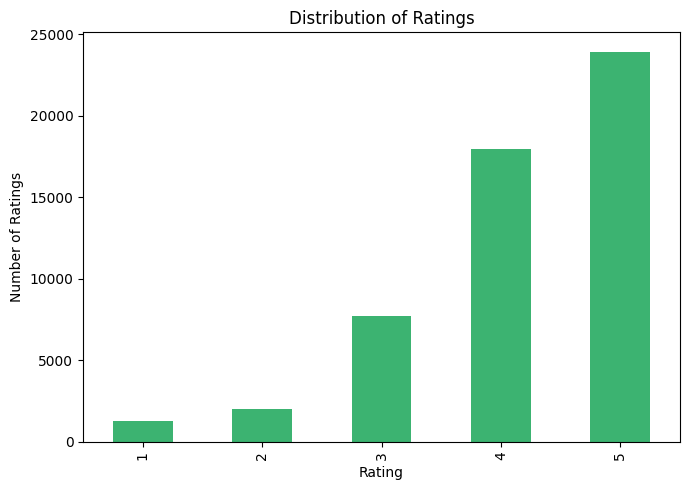

Chart saved as rating_distribution.png


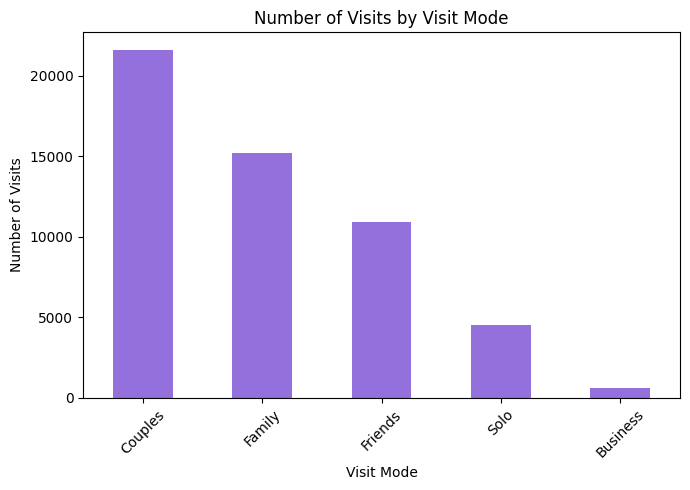

Chart saved as visit_mode_breakdown.png


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

master = pd.read_csv("master_cleaned.csv")

continent_counts = master["Continent"].value_counts()

plt.figure(figsize=(8, 5))
continent_counts.plot(kind="bar", color="skyblue")
plt.title("Number of Visits by Continent")
plt.xlabel("Continent")
plt.ylabel("Number of Visits")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("continent_visits.png")
plt.show()

print("Chart saved as continent_visits.png")

type_counts = master["AttractionType"].value_counts().head(10)

plt.figure(figsize=(9, 5))
type_counts.plot(kind="barh", color="coral")
plt.title("Top 10 Attraction Types by Number of Visits")
plt.xlabel("Number of Visits")
plt.ylabel("Attraction Type")
plt.gca().invert_yaxis()  # so the biggest bar is on top
plt.tight_layout()
plt.savefig("attraction_type_popularity.png")
plt.show()

print("Chart saved as attraction_type_popularity.png")

# Chart 3: Distribution of ratings
plt.figure(figsize=(7, 5))
master["Rating"].value_counts().sort_index().plot(kind="bar", color="mediumseagreen")
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.tight_layout()
plt.savefig("rating_distribution.png")
plt.show()

print("Chart saved as rating_distribution.png")

mode_counts = master["VisitMode"].value_counts()

plt.figure(figsize=(7, 5))
mode_counts.plot(kind="bar", color="mediumpurple")
plt.title("Number of Visits by Visit Mode")
plt.xlabel("Visit Mode")
plt.ylabel("Number of Visits")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("visit_mode_breakdown.png")
plt.show()

print("Chart saved as visit_mode_breakdown.png")

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# Load the cleaned dataset
master = pd.read_csv("master_cleaned.csv")

# Step 1: Split the data FIRST, before creating any average-based features
# This prevents "leakage" (the model seeing answers it shouldn't have)
train_df, test_df = train_test_split(master, test_size=0.2, random_state=42)

print("Training rows:", len(train_df))
print("Testing rows:", len(test_df))

# Step 2: Calculate each attraction's average rating, using ONLY the training data
attraction_avg_rating = train_df.groupby("Attraction")["Rating"].mean()
overall_avg_rating = train_df["Rating"].mean()  # fallback for any unseen attraction

# Step 3: Apply these average ratings as a new feature to both sets
train_df["AttractionAvgRating"] = train_df["Attraction"].map(attraction_avg_rating)
test_df["AttractionAvgRating"] = test_df["Attraction"].map(attraction_avg_rating).fillna(overall_avg_rating)

# Step 4: Pick our features
features = ["Attraction", "AttractionType", "VisitMode", "VisitYear", "VisitMonth", "AttractionAvgRating"]
target = "Rating"

X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target]

# Step 5: One-hot encode text columns (fit on train, apply same columns to test)
X_train_encoded = pd.get_dummies(X_train, columns=["Attraction", "AttractionType", "VisitMode"])
X_test_encoded = pd.get_dummies(X_test, columns=["Attraction", "AttractionType", "VisitMode"])

# Make sure test set has exactly the same columns as train (fill any gaps with 0)
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

# Step 6: Train the model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train_encoded, y_train)

# Step 7: Evaluate
predictions = model.predict(X_test_encoded)
r2 = r2_score(y_test, predictions)
mse = mean_squared_error(y_test, predictions)

print("\nModel Performance:")
print(f"R² score: {r2:.3f}")
print(f"Mean Squared Error: {mse:.3f}")

# Step 8: Save this model so we can use it later in the Streamlit app
import joblib
joblib.dump(model, "regression_model.pkl")
joblib.dump(X_train_encoded.columns.tolist(), "regression_columns.pkl")
print("\nModel saved as regression_model.pkl")

Training rows: 42344
Testing rows: 10586

Model Performance:
R² score: 0.051
Mean Squared Error: 0.894

Model saved as regression_model.pkl


In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
import joblib

# Load the cleaned dataset
master = pd.read_csv("master_cleaned.csv")

# Step 1: Pick features (inputs) and target (what we want to predict)
features = ["Attraction", "AttractionType", "Continent", "Region", "VisitYear", "VisitMonth"]
target = "VisitMode"

X = master[features]
y = master[target]

# Step 2: One-hot encode text feature columns
X_encoded = pd.get_dummies(X, columns=["Attraction", "AttractionType", "Continent", "Region"])

# Step 3: Convert the target labels (text) into numbers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Step 4: Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

# Step 5: Calculate sample weights so rare categories matter more during training
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

# Step 6: Train an XGBoost Classifier, using the sample weights
model = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train, sample_weight=sample_weights)

# Step 7: Test the model
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print("\nModel Performance:")
print(f"Accuracy: {accuracy:.3f}")
print("\nDetailed report:")
print(classification_report(y_test, predictions, target_names=label_encoder.classes_))

# Step 8: Save the model, label encoder, and column list for later use
joblib.dump(model, "classification_model.pkl")
joblib.dump(label_encoder, "classification_label_encoder.pkl")
joblib.dump(X_train.columns.tolist(), "classification_columns.pkl")
print("\nModel saved as classification_model.pkl")

Training rows: 42344
Testing rows: 10586

Model Performance:
Accuracy: 0.357

Detailed report:
              precision    recall  f1-score   support

    Business       0.04      0.50      0.07       125
     Couples       0.53      0.44      0.48      4324
      Family       0.51      0.41      0.45      3043
     Friends       0.29      0.14      0.19      2189
        Solo       0.13      0.27      0.18       905

    accuracy                           0.36     10586
   macro avg       0.30      0.35      0.27     10586
weighted avg       0.44      0.36      0.38     10586


Model saved as classification_model.pkl


In [11]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# Load the cleaned dataset
master = pd.read_csv("master_cleaned.csv")

# Step 1: Build a "user-item matrix"
# Rows = users, Columns = attractions, Values = rating given (0 if never rated)
user_item_matrix = master.pivot_table(
    index="UserId", columns="Attraction", values="Rating", fill_value=0
)

print("User-item matrix shape:", user_item_matrix.shape)

# Step 2: Calculate similarity between ATTRACTIONS instead of users
# This is much smaller (30x30) and captures "attractions that tend to be liked together"
item_similarity = cosine_similarity(user_item_matrix.T)  # .T flips rows/columns
item_similarity_df = pd.DataFrame(
    item_similarity, index=user_item_matrix.columns, columns=user_item_matrix.columns
)

print("\nAttraction similarity matrix shape:", item_similarity_df.shape)

# Step 3: Write a function that recommends attractions for a given user
def recommend_attractions(user_id, num_recommendations=5):
    if user_id not in user_item_matrix.index:
        return "User not found in dataset."

    # Get this user's ratings
    user_ratings = user_item_matrix.loc[user_id]
    already_rated = user_ratings[user_ratings > 0].index.tolist()

    if not already_rated:
        return "This user hasn't rated anything yet."

    # For each attraction the user liked, find similar attractions,
    # weighted by how much the user liked the original one
    scores = pd.Series(0, index=user_item_matrix.columns, dtype=float)
    for attraction in already_rated:
        similar_scores = item_similarity_df[attraction] * user_ratings[attraction]
        scores += similar_scores

    # Remove attractions already visited, then sort by predicted interest
    scores = scores.drop(labels=already_rated, errors="ignore")
    recommendations = scores.sort_values(ascending=False).head(num_recommendations)

    return recommendations

# Step 4: Test it on a real user from the dataset
test_user = user_item_matrix.index[0]
print(f"\nTop recommendations for User {test_user}:")
print(recommend_attractions(test_user))
 # Step 5: Save the matrices so the Streamlit app can reuse them instantly
import joblib

joblib.dump(user_item_matrix, "user_item_matrix.pkl")
joblib.dump(item_similarity_df, "item_similarity.pkl")

print("\nSaved user_item_matrix.pkl and item_similarity.pkl")

User-item matrix shape: (33530, 30)

Attraction similarity matrix shape: (30, 30)

Top recommendations for User 14:
Attraction
Tegenungan Waterfall    1.717209
Tanah Lot Temple        1.048467
Uluwatu Temple          0.952040
Waterbom Bali           0.779154
Seminyak Beach          0.755291
dtype: float64

Saved user_item_matrix.pkl and item_similarity.pkl
